#  House Price Prediction model

## Dataset Source

The dataset used in this project is derived from real estate listings available on Indian property platforms such as MagicBricks and 99acres.

It contains raw and semi-structured data including property descriptions, pricing formats (e.g., "1.5 Cr", "50 Lac"), and various property features such as location, area, furnishing status, and amenities.

Due to its real-world nature, the dataset required extensive data cleaning and preprocessing before model training.

##  Problem Statement

The objective of this project is to build a Machine Learning model that can accurately predict the price of residential properties based on various features such as location, area, furnishing status, and other property characteristics.

This model will help buyers, sellers, and real estate platforms make **data-driven decisions**.

---

##  Dataset Description

The dataset contains multiple features related to residential properties.

---

##  Column Definitions

###  Basic Identification

- **Index**  
  Unique identifier for each record (not useful for modeling, usually removed)

- **Title**  
  Short title of the property listing  
  *Example: "3 BHK Flat in Gomti Nagar"*

- **Description**  
  Detailed information about the property (can be used for NLP in advanced models)

---

###  Price Information

- **Amount (in rupees)**  
  Raw listed price (may contain text like "50 Lac")

- **Price (in rupees)** 
  Final numeric price of the property (**Target Variable**)

---

###  Location Feature

- **Location**  
  Area where the property is located  
  *Example: Gomti Nagar, Indira Nagar*

---

###  Area Features

- **Carpet Area**  
  Actual usable area inside the house (in sq ft)

- **Super Area**  
  Total built-up area including common spaces

- **Plot Area**  
  Total land area (important for independent houses)

- **Dimensions**  
  Physical dimensions of the property (Length × Width)

---

###  Property Details

- **Status**  
  Property condition (Ready to Move / Under Construction)

- **Floor**  
  Floor number of the property

- **Transaction**  
  Type of transaction (New / Resale)

- **Ownership**  
  Ownership type (Freehold / Leasehold)

---

###  Interior Features

- **Furnishing**  
  Furnishing status (Furnished / Semi-Furnished / Unfurnished)

- **Facing**  
  Direction the property faces (North, East, etc.)

- **Overlooking**  
  View from the property (Park, Road, etc.)

---

###  Society Information

- **Society**  
  Name of the apartment or housing society

---

###  Utility Features

- **Bathroom**  
  Number of bathrooms

- **Balcony**  
  Number of balconies

- **Car Parking**  
  Parking availability (Yes/No or count)

---

##  Target Variable

- **Price (in rupees)**

---

##  Features (Input Variables)

All columns except:
- Index  
- Price (in rupees)

---

##  Data Preprocessing Requirements

### 1. Data Cleaning
- Convert text values:
  - "50 Lac" → 5000000  
  - "1200 sqft" → 1200  
- Extract numeric values using regular expressions

### 2. Handling Missing Values
- Fill or remove null values in:
  - Carpet Area  
  - Balcony  
  - Bathroom  

### 3. Encoding Categorical Variables
- Convert categories into numeric form:
  - Location  
  - Furnishing  
  - Facing  
  - Ownership  

### 4. Remove Irrelevant Columns
- Drop:
  - Index  
  - Title (optional)  
  - Description (optional for basic model)  

---

##  Next Steps

- Feature Engineering (e.g., price per sqft)
- Model Training:
  - Linear Regression  
  - Random Forest  
- Model Evaluation:
  - R² Score  
  - MAE  
  - RMSE  

---


In [1011]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

### import dataset

In [1012]:
df=pd.read_csv(r"house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


## Sample Data Row (Raw)

Below is a raw property listing from the dataset:

---

###  Property Details

| Column                | Value |
|----------------------|------|
| Index                | 33 |
| Title                | 3 BHK Ready to Occupy Flat for sale in Rustomjee Athena Balkum Naka |
| Description          | This exquisite 3 BHK Flat is offered for sale in Balkum Naka, Thane... |
| Amount (in rupees)   | 1.42 Cr |
| Price (in rupees)    | 11008 |
| Location             | Thane |
| Carpet Area          | 849 sqft |
| Status               | Ready to Move |
| Floor                | 1 out of 27 |
| Transaction          | Resale |
| Furnishing           | Semi-Furnished |
| Facing               | East |
| Overlooking          | Garden/Park, Main Road |
| Society              | Rustomjee Athena |
| Bathroom             | 3 |
| Balcony              | NaN |
| Car Parking          | 1 Covered |
| Ownership            | Freehold |
| Super Area           | NaN |
| Dimensions           | NaN |
| Plot Area            | NaN |

---

##  Issues in Raw Data

- **Price inconsistency**
  - "1.42 Cr" (text format)
  - "11008" (unclear meaning)

- **Mixed data types**
  - Carpet Area → "849 sqft" (string)
  - Floor → "1 out of 27" (text)

- **Missing values**
  - Balcony
  - Super Area
  - Dimensions
  - Plot Area

- **Categorical text**
  - Furnishing, Facing, Ownership, etc.

---

##  Required Data Cleaning

### 1. Convert Price
- "1.42 Cr" → 14200000

### 2. Extract Numeric Values
- "849 sqft" → 849
- "1 out of 27" → Floor = 1, Total Floors = 27

### 3. Handle Missing Values
- Fill or drop NaN columns

### 4. Encode Categories
- Semi-Furnished → numeric
- East → numeric
- Freehold → numeric

---

##  Final Goal

Convert this raw row into a clean structured format like:

| Feature        | Value |
|---------------|------|
| Price         | 14200000 |
| Location      | Thane |
| Carpet Area   | 849 |
| Floor         | 1 |
| Total Floors  | 27 |
| Furnishing    | 1 |
| Bathroom      | 3 |
| Parking       | 1 |

In [1013]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [1014]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

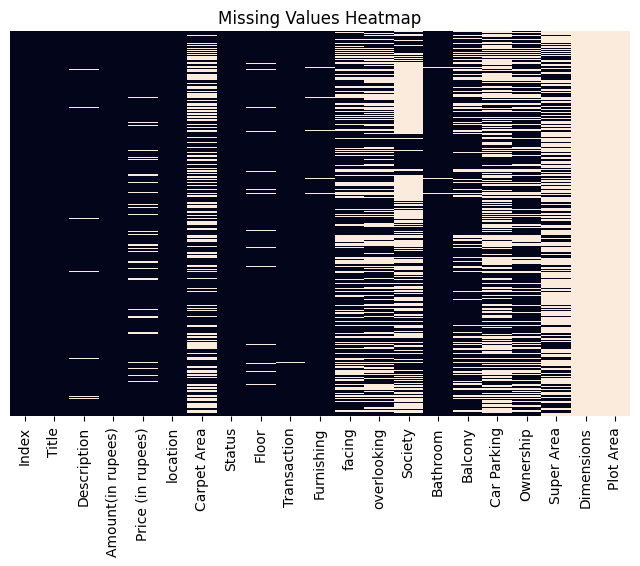

In [1015]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


In [1016]:
df.drop(columns=['Index', 'Title', 'Description','Dimensions','Plot Area'], inplace=True,axis=1)

In [1017]:
df['Amount(in rupees)'].value_counts()

Amount(in rupees)
Call for Price    9684
85 Lac            5264
65 Lac            4229
60 Lac            3869
70 Lac            3801
                  ... 
8.8 Lac              1
80 Cr                1
1.5 Lac              1
24.4 Lac             1
9.90 Cr              1
Name: count, Length: 1561, dtype: int64

In [1018]:
def convert_Amt(value):
    if pd.isna(value):
        return np.nan
    value = str(value).lower().strip()
    value = value.replace(',', '')
    
    # handle "call for price"
    if 'call' in value:
        return np.nan
    
    # extract number
    number = re.findall(r'\d+\.?\d*', value)
    if not number:
        return np.nan
    
    number = float(number[0])
    
    # convert based on unit
    if 'cr' in value:
        return number * 10_000_000
    elif 'lac' in value or 'lakh' in value:
        return number * 100_000
    else:
        return number


In [1019]:
df['Amount(in rupees)'] = df['Amount(in rupees)'].apply(convert_Amt)
df = df.dropna(subset=['Amount(in rupees)'])


In [1020]:
df['Amount(in rupees)'].value_counts()

Amount(in rupees)
8500000.0      5264
6500000.0      4229
6000000.0      3869
7000000.0      3801
3500000.0      3369
               ... 
880000.0          1
800000000.0       1
150000.0          1
2440000.0         1
99000000.0        1
Name: count, Length: 1559, dtype: int64

In [1021]:
df = df.dropna(subset=['Price (in rupees)'])
df['Price (in rupees)'].value_counts()


Price (in rupees)
4000.0     2463
5000.0     2286
10000.0    2273
3200.0     1479
18000.0    1420
           ... 
10149.0       1
7131.0        1
4006.0        1
6626.0        1
13799.0       1
Name: count, Length: 10958, dtype: int64

In [1022]:
df['Balcony'].value_counts()

Balcony
2       47983
1       42068
3       24586
4        9183
5         802
6         126
> 10       15
7          14
10         13
8          13
9           1
Name: count, dtype: int64

In [1023]:
df['Bathroom'].value_counts()
# data type object 

Bathroom
2       84314
3       52741
1       14950
4       14148
5        2685
6         178
7          32
> 10       28
8          14
9          11
10         11
Name: count, dtype: int64

In [1024]:
for col in ['Bathroom', 'Balcony']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[['Bathroom', 'Balcony']] = df[
    ['Bathroom', 'Balcony']
].fillna(
    df[['Bathroom', 'Balcony']].median()
)

In [1025]:
df['Car Parking'].value_counts()

Car Parking
1 Covered      36811
1 Covered,     16294
2 Covered       9061
1 Open          7577
2 Covered,      3630
               ...  
207 Covered        1
205 Covered        1
11 Covered,        1
123 Open           1
702 Open           1
Name: count, Length: 205, dtype: int64

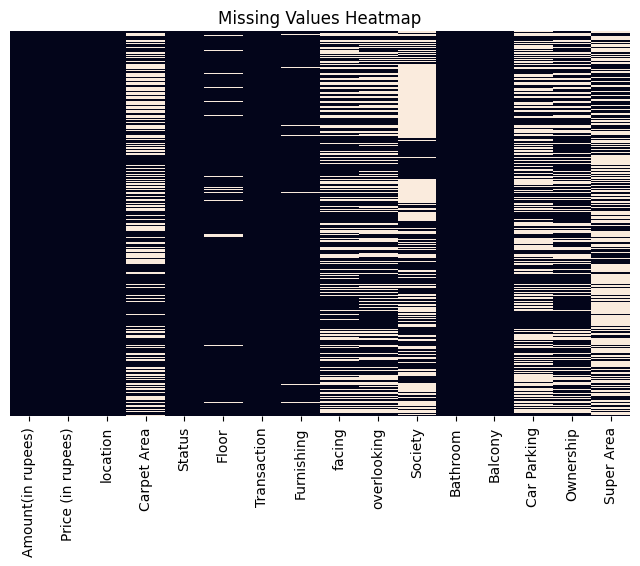

In [1026]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


In [1027]:
df['Carpet Area'].value_counts()

Carpet Area
1000 sqft    4901
900 sqft     4568
1300 sqft    3410
600 sqft     2183
1600 sqft    2140
             ... 
299 sqft        1
1479 sqft       1
2722 sqft       1
169 sqft        1
407 sqft        1
Name: count, Length: 2590, dtype: int64

In [1028]:
def extract_sqft(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'(\d+\.?\d*)', value)
    return float(match.group(1)) if match else np.nan



In [1029]:
df['Carpet_Area_sqft'] = df['Carpet Area'].apply(extract_sqft)
df.drop(columns=['Carpet Area'], inplace=True,axis=1)


In [1030]:
df['Carpet_Area_sqft'].value_counts()

Carpet_Area_sqft
1000.0    4904
900.0     4569
1300.0    3410
600.0     2184
1600.0    2141
          ... 
1097.0       1
513.0        1
267.0        1
264.0        1
7000.0       1
Name: count, Length: 2362, dtype: int64

In [1031]:
df['Carpet_Area_sqft'] = df['Carpet_Area_sqft'].fillna(
    df.groupby('location')['Carpet_Area_sqft'].transform('median')
)

In [1032]:
df.head()

,Amount(in rupees),Price (in rupees),location,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Carpet_Area_sqft
0,4200000.0,6000.0,thane,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,500.0
1,9800000.0,13799.0,thane,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,2.0,1 Open,Freehold,NaN,473.0
2,14000000.0,17500.0,thane,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,2.0,1 Covered,Freehold,NaN,779.0
4,16000000.0,18824.0,thane,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,2.0,1 Covered,Co-operative Society,NaN,635.0
5,4500000.0,6618.0,thane,Ready to Move,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1.0,1.0,NaN,Co-operative Society,680 sqft,639.5


In [1033]:
df['Floor'].value_counts()

Floor
1 out of 4                  11639
2 out of 4                  10636
3 out of 4                   7624
1 out of 3                   6616
4 out of 4                   5654
                            ...  
7 out of 76                     1
10 out of 33                    1
Upper Basement out of 24        1
Lower Basement out of 18        1
7 out of 70                     1
Name: count, Length: 931, dtype: int64

In [1034]:
def process_floor(value):
    if pd.isna(value):
        return np.nan, np.nan, 0
    
    value = str(value).lower()
    
    # Basement handling
    if 'basement' in value:
        total_match = re.search(r'out of (\d+)', value)
        total = int(total_match.group(1)) if total_match else np.nan
        return -1, total, 1   # floor = -1 for basement
    
    # Normal case: "X out of Y"
    match = re.search(r'(\d+)\s*out of\s*(\d+)', value)
    if match:
        floor = int(match.group(1))
        total = int(match.group(2))
        return floor, total, 0
    
    return np.nan, np.nan, 0

In [1035]:
df[['Floor_No', 'Total_Floors', 'Is_Basement']] = df['Floor'].apply(
    lambda x: pd.Series(process_floor(x))
)

df.drop(columns=['Floor'], inplace=True)

In [1036]:
df['Floor_No'].fillna(0, inplace=True)
df['Total_Floors'].fillna(df['Total_Floors'].median(), inplace=True)
df['Is_Basement'].fillna(0, inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\166000651.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Floor_No'].fillna(0, inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\166000651.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [1037]:
df.head()

,Amount(in rupees),Price (in rupees),location,Status,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Carpet_Area_sqft,Floor_No,Total_Floors,Is_Basement
0,4200000.0,6000.0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,NaN,NaN,500.0,10.0,11.0,0.0
1,9800000.0,13799.0,thane,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,2.0,1 Open,Freehold,NaN,473.0,3.0,22.0,0.0
2,14000000.0,17500.0,thane,Ready to Move,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,2.0,1 Covered,Freehold,NaN,779.0,10.0,29.0,0.0
4,16000000.0,18824.0,thane,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,2.0,1 Covered,Co-operative Society,NaN,635.0,20.0,42.0,0.0
5,4500000.0,6618.0,thane,Ready to Move,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1.0,1.0,NaN,Co-operative Society,680 sqft,639.5,2.0,7.0,0.0


In [1038]:
df['Ownership'].value_counts()

Ownership
Freehold                102415
Leasehold                 5111
Co-operative Society      3109
Power Of Attorney          994
Name: count, dtype: int64

In [1039]:
df['Ownership'].fillna('Unknown', inplace=True)
df['Ownership'] = df['Ownership'].replace({
    'Power Of Attorney': 'Other',
    'Unknown': 'Other'
})

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\534423847.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Ownership'].fillna('Unknown', inplace=True)


In [1040]:
df['Super Area'].isnull().sum()
df['Super Area'].value_counts()

Super Area
1100 sqft    2567
1332 sqft    2110
1500 sqft    1998
500 sqft     1651
1000 sqft    1294
             ... 
468 sqft        1
2053 sqft       1
2201 sqft       1
1996 sqft       1
3215 sqft       1
Name: count, Length: 2897, dtype: int64

In [1041]:
df.drop(columns=['Super Area'], inplace=True)

In [1042]:
df.head()

,Amount(in rupees),Price (in rupees),location,Status,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Carpet_Area_sqft,Floor_No,Total_Floors,Is_Basement
0,4200000.0,6000.0,thane,Ready to Move,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1.0,2.0,NaN,Other,500.0,10.0,11.0,0.0
1,9800000.0,13799.0,thane,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2.0,2.0,1 Open,Freehold,473.0,3.0,22.0,0.0
2,14000000.0,17500.0,thane,Ready to Move,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2.0,2.0,1 Covered,Freehold,779.0,10.0,29.0,0.0
4,16000000.0,18824.0,thane,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2.0,2.0,1 Covered,Co-operative Society,635.0,20.0,42.0,0.0
5,4500000.0,6618.0,thane,Ready to Move,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1.0,1.0,NaN,Co-operative Society,639.5,2.0,7.0,0.0


In [1043]:
df['Society'].isnull().sum()

np.int64(97433)

In [1044]:
df.drop(columns=['Society'], inplace=True)

In [1045]:
df['location'].value_counts()

location
new-delhi      24849
bangalore      23168
kolkata        19562
gurgaon        18238
ahmedabad      12178
               ...  
ahmadnagar        28
pondicherry       27
palakkad          27
navsari           26
madurai           21
Name: count, Length: 81, dtype: int64

In [1046]:
df['location'].isnull().sum()

np.int64(0)

In [1047]:
threshold = 100  # you can tune this

location_counts = df['location'].value_counts()

rare_locations = location_counts[location_counts < threshold].index

df['location'] = df['location'].replace(rare_locations, 'Other')

In [1048]:
df = pd.get_dummies(df, columns=['location'], drop_first=True)

In [1049]:
df.head()

,Amount(in rupees),Price (in rupees),Status,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,...,location_thrissur,location_trichy,location_trivandrum,location_udaipur,location_vadodara,location_vapi,location_varanasi,location_vijayawada,location_visakhapatnam,location_zirakpur
0,4200000.0,6000.0,Ready to Move,Resale,Unfurnished,NaN,NaN,1.0,2.0,NaN,...,False,False,False,False,False,False,False,False,False,False
1,9800000.0,13799.0,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,2.0,2.0,1 Open,...,False,False,False,False,False,False,False,False,False,False
2,14000000.0,17500.0,Ready to Move,Resale,Unfurnished,East,Garden/Park,2.0,2.0,1 Covered,...,False,False,False,False,False,False,False,False,False,False
4,16000000.0,18824.0,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,2.0,1 Covered,...,False,False,False,False,False,False,False,False,False,False
5,4500000.0,6618.0,Ready to Move,Resale,Unfurnished,East,"Garden/Park, Main Road",1.0,1.0,NaN,...,False,False,False,False,False,False,False,False,False,False


In [1050]:
df['facing'].value_counts()

facing
East            49486
North - East    23172
North           15094
West             7745
South            3995
North - West     3769
South - East     2529
South -West      2024
Name: count, dtype: int64

In [1051]:
df['facing'].isnull().sum()

np.int64(62052)

In [1052]:
df['facing'].fillna('Unknown', inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\2149014988.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('Unknown', inplace=True)


In [1053]:
df['facing'] = df['facing'].str.strip().str.lower()

df['facing'] = df['facing'].replace({
    'north - east': 'north-east',
    'north - west': 'north-west',
    'south - east': 'south-east',
    'south -west': 'south-west'
})

In [1054]:
df = pd.get_dummies(df, columns=['facing'], drop_first=True)

In [1055]:
df['Furnishing'].value_counts()

Furnishing
Semi-Furnished    79574
Unfurnished       70303
Furnished         17929
Name: count, dtype: int64

In [1056]:
df['Furnishing'].isnull().sum()

np.int64(2060)

In [1057]:
df['Furnishing'].fillna('Unknown', inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\625969351.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Furnishing'].fillna('Unknown', inplace=True)


In [1058]:
df['Furnishing'] = df['Furnishing'].map({
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2,
    'Unknown': -1
})

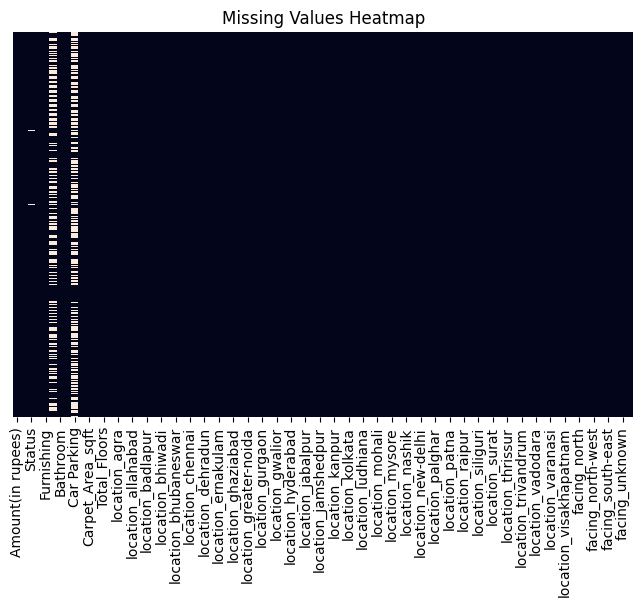

In [1059]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

In [1060]:
df['Status'].value_counts()

Status
Ready to Move    169271
Name: count, dtype: int64

In [1061]:
df['Status'].isnull().sum()

np.int64(595)

In [1062]:
df.drop(columns=['Status'], inplace=True)

In [1063]:
df['overlooking'].value_counts()

overlooking
Main Road                         29175
Garden/Park, Main Road            25510
Garden/Park                       21556
Garden/Park, Pool, Main Road      12225
Pool, Garden/Park, Main Road       3356
Garden/Park, Pool                  2807
Main Road, Garden/Park, Pool       1353
Pool, Main Road                    1125
Pool                                986
Main Road, Garden/Park              651
Pool, Garden/Park                   408
Garden/Park, Main Road, Pool         37
Main Road, Pool                      11
Main Road, Pool, Garden/Park          8
Pool, Main Road, Garden/Park          6
Main Road, Not Available              4
Garden/Park, Not Available            1
Pool, Main Road, Not Available        1
Name: count, dtype: int64

In [1064]:
df['overlooking'].isnull().sum()

np.int64(70646)

In [1065]:
df['overlooking'].fillna('None', inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\651248815.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['overlooking'].fillna('None', inplace=True)


In [1066]:
df['Park_View'] = df['overlooking'].apply(
    lambda x: 1 if 'Garden/Park' in str(x) else 0
)

df['Road_View'] = df['overlooking'].apply(
    lambda x: 1 if 'Main Road' in str(x) else 0
)

df['Pool_View'] = df['overlooking'].apply(
    lambda x: 1 if 'Pool' in str(x) else 0
)

In [1067]:
df.drop(columns=['overlooking'], inplace=True)

In [1068]:
df.head()

,Amount(in rupees),Price (in rupees),Transaction,Furnishing,Bathroom,Balcony,Car Parking,Ownership,Carpet_Area_sqft,Floor_No,...,facing_north-east,facing_north-west,facing_south,facing_south-east,facing_south-west,facing_unknown,facing_west,Park_View,Road_View,Pool_View
0,4200000.0,6000.0,Resale,0,1.0,2.0,NaN,Other,500.0,10.0,...,False,False,False,False,False,True,False,0,0,0
1,9800000.0,13799.0,Resale,1,2.0,2.0,1 Open,Freehold,473.0,3.0,...,False,False,False,False,False,False,False,1,0,0
2,14000000.0,17500.0,Resale,0,2.0,2.0,1 Covered,Freehold,779.0,10.0,...,False,False,False,False,False,False,False,1,0,0
4,16000000.0,18824.0,Resale,0,2.0,2.0,1 Covered,Co-operative Society,635.0,20.0,...,False,False,False,False,False,False,True,1,1,0
5,4500000.0,6618.0,Resale,0,1.0,1.0,NaN,Co-operative Society,639.5,2.0,...,False,False,False,False,False,False,False,1,1,0


In [1069]:
df['Car Parking'].value_counts()

Car Parking
1 Covered      36811
1 Covered,     16294
2 Covered       9061
1 Open          7577
2 Covered,      3630
               ...  
207 Covered        1
205 Covered        1
11 Covered,        1
123 Open           1
702 Open           1
Name: count, Length: 205, dtype: int64

In [1070]:
df['Car Parking'].isnull().sum()

np.int64(90950)

In [1071]:
df['Car Parking'].fillna('0', inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22236\1837516175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Car Parking'].fillna('0', inplace=True)


In [1072]:
import re

def extract_parking_count(x):
    match = re.search(r'(\d+)', str(x))
    return int(match.group(1)) if match else 0

df['Parking_Count'] = df['Car Parking'].apply(extract_parking_count)

In [1073]:
df['Parking_Count'] = df['Parking_Count'].clip(upper=5)

In [1074]:
def extract_parking_type(x):
    x = str(x).lower()
    if 'covered' in x:
        return 'covered'
    elif 'open' in x:
        return 'open'
    else:
        return 'none'

df['Parking_Type'] = df['Car Parking'].apply(extract_parking_type)

In [1075]:
df = pd.get_dummies(df, columns=['Parking_Type'], drop_first=True)

In [1076]:
df.drop(columns=['Car Parking'], inplace=True)

In [1077]:
df.head()

,Amount(in rupees),Price (in rupees),Transaction,Furnishing,Bathroom,Balcony,Ownership,Carpet_Area_sqft,Floor_No,Total_Floors,...,facing_south-east,facing_south-west,facing_unknown,facing_west,Park_View,Road_View,Pool_View,Parking_Count,Parking_Type_none,Parking_Type_open
0,4200000.0,6000.0,Resale,0,1.0,2.0,Other,500.0,10.0,11.0,...,False,False,True,False,0,0,0,0,True,False
1,9800000.0,13799.0,Resale,1,2.0,2.0,Freehold,473.0,3.0,22.0,...,False,False,False,False,1,0,0,1,False,True
2,14000000.0,17500.0,Resale,0,2.0,2.0,Freehold,779.0,10.0,29.0,...,False,False,False,False,1,0,0,1,False,False
4,16000000.0,18824.0,Resale,0,2.0,2.0,Co-operative Society,635.0,20.0,42.0,...,False,False,False,True,1,1,0,1,False,False
5,4500000.0,6618.0,Resale,0,1.0,1.0,Co-operative Society,639.5,2.0,7.0,...,False,False,False,False,1,1,0,0,True,False


In [1078]:
df['Transaction'].value_counts()

Transaction
Resale          129333
New Property     40521
Other                4
Rent/Lease           2
Name: count, dtype: int64

In [1079]:
df['Transaction'] = df['Transaction'].replace({
    'Other': 'Resale',
    'Rent/Lease': 'Resale'
})

In [1080]:
df['Transaction'] = df['Transaction'].map({
    'Resale': 0,
    'New Property': 1
})

In [1081]:
df = pd.get_dummies(df, columns=['Transaction'], drop_first=True)

In [1082]:
df = pd.get_dummies(df, columns=['Ownership'], drop_first=True)

In [1083]:
df=df.astype('int64')

# Feature Selection

In [1084]:
df.columns

Index(['Amount(in rupees)', 'Price (in rupees)', 'Furnishing', 'Bathroom',
       'Balcony', 'Carpet_Area_sqft', 'Floor_No', 'Total_Floors',
       'Is_Basement', 'location_agra', 'location_ahmedabad',
       'location_allahabad', 'location_aurangabad', 'location_badlapur',
       'location_bangalore', 'location_bhiwadi', 'location_bhopal',
       'location_bhubaneswar', 'location_chandigarh', 'location_chennai',
       'location_coimbatore', 'location_dehradun', 'location_durgapur',
       'location_ernakulam', 'location_faridabad', 'location_ghaziabad',
       'location_goa', 'location_greater-noida', 'location_guntur',
       'location_gurgaon', 'location_guwahati', 'location_gwalior',
       'location_haridwar', 'location_hyderabad', 'location_indore',
       'location_jabalpur', 'location_jaipur', 'location_jamshedpur',
       'location_kalyan', 'location_kanpur', 'location_kochi',
       'location_kolkata', 'location_lucknow', 'location_ludhiana',
       'location_mangalore', 'lo

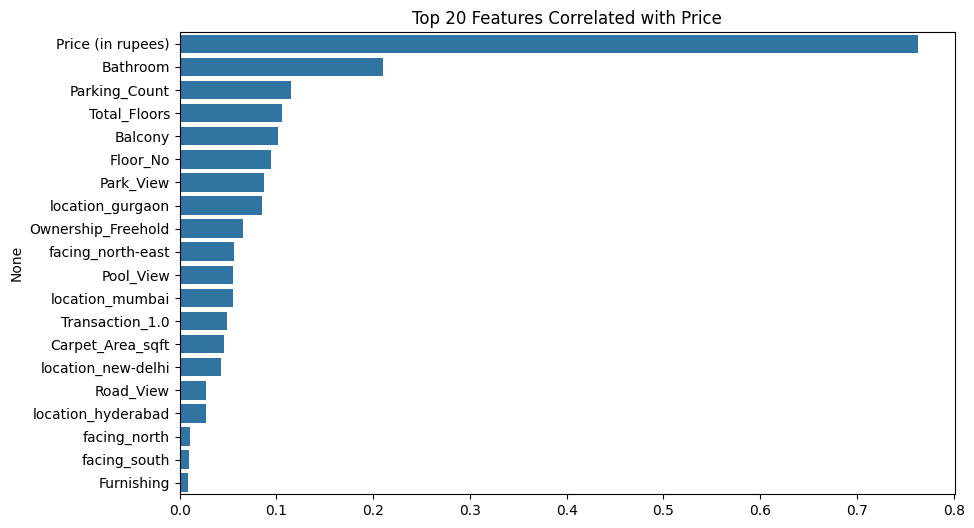

In [1085]:


# Compute correlation
corr = df.corr()['Amount(in rupees)'].sort_values(ascending=False)

# Visualize top 20 correlated features
top_corr = corr[1:21]  # skip self
plt.figure(figsize=(10,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top 20 Features Correlated with Price")
plt.show()